# Выбор локации для скважины

Задачи
* Нужно решить, где бурить новую скважину.
* Построить модель машинного обучения, которая поможет определить регион, где добыча принесёт наибольшую прибыль.
* Проанализировать возможную прибыль и риски

Шаги для выбора локации:

- В избранном регионе ищут месторождения, для каждого определяют значения признаков;
- Строят модель и оценивают объём запасов;
- Выбирают месторождения с самым высокими оценками значений. Количество месторождений зависит от бюджета компании и стоимости разработки одной скважины;
- Прибыль равна суммарной прибыли отобранных месторождений.

## Загрузка и подготовка данных

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy import stats as st
from tqdm import tqdm

plt.rcParams["figure.figsize"] = (20,8)

In [17]:
"""Globals"""
RESEARCH_WELLS = 500
SELECTED_WELLS = 200
BUDGET = 10 * 10**9
REVENUE_PER_THOUSAND = 450 * 10**3
ALPHA = .025

In [18]:
!wget  -O 'geo_data_0.csv' -q 'https://code.s3.yandex.net/datasets/geo_data_0.csv'
!wget  -O 'geo_data_1.csv' -q 'https://code.s3.yandex.net/datasets/geo_data_1.csv'
!wget  -O 'geo_data_2.csv' -q 'https://code.s3.yandex.net/datasets/geo_data_2.csv'

In [19]:
df_0 = pd.read_csv('geo_data_0.csv')
df_0

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647
...,...,...,...,...,...
99995,DLsed,0.971957,0.370953,6.075346,110.744026
99996,QKivN,1.392429,-0.382606,1.273912,122.346843
99997,3rnvd,1.029585,0.018787,-1.348308,64.375443
99998,7kl59,0.998163,-0.528582,1.583869,74.040764


In [20]:
df_1 = pd.read_csv('geo_data_1.csv')
df_1

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305
...,...,...,...,...,...
99995,QywKC,9.535637,-6.878139,1.998296,53.906522
99996,ptvty,-10.160631,-12.558096,5.005581,137.945408
99997,09gWa,-7.378891,-3.084104,4.998651,137.945408
99998,rqwUm,0.665714,-6.152593,1.000146,30.132364


In [21]:
df_2 = pd.read_csv('geo_data_2.csv')
df_2

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746
...,...,...,...,...,...
99995,4GxBu,-1.777037,1.125220,6.263374,172.327046
99996,YKFjq,-1.261523,-0.894828,2.524545,138.748846
99997,tKPY3,-1.199934,-2.957637,5.219411,157.080080
99998,nmxp2,-2.419896,2.417221,-5.548444,51.795253


In [22]:
regions = [df_0, df_1, df_2]

### Описание данных

* `id` — уникальный идентификатор скважины;
* `f0, f1, f2` — три признака точек (неважно, что они означают, но сами признаки значимы);
* `product` — объём запасов в скважине (тыс. баррелей).

### Условия задачи:
* Для обучения модели подходит только линейная регрессия (остальные — недостаточно предсказуемые).
* При разведке региона исследуют 500 точек, из которых с помощью машинного обучения выбирают 200 лучших для разработки.
* Бюджет на разработку скважин в регионе — 10 млрд рублей.
* При нынешних ценах один баррель сырья приносит 450 рублей дохода. Доход с каждой единицы продукта составляет 450 тыс. рублей, поскольку объём указан в тысячах баррелей.
* После оценки рисков нужно оставить лишь те регионы, в которых вероятность убытков меньше 2.5%. Среди них выбирают регион с наибольшей средней прибылью.

In [23]:
cnt = 0
for region in regions:
    print(f'region {cnt}:')
    print(region['product'].describe().to_frame(), '\n')
    cnt+=1

region 0:
             product
count  100000.000000
mean       92.500000
std        44.288691
min         0.000000
25%        56.497507
50%        91.849972
75%       128.564089
max       185.364347 

region 1:
             product
count  100000.000000
mean       68.825000
std        45.944423
min         0.000000
25%        26.953261
50%        57.085625
75%       107.813044
max       137.945408 

region 2:
             product
count  100000.000000
mean       95.000000
std        44.749921
min         0.000000
25%        59.450441
50%        94.925613
75%       130.595027
max       190.029838 



In [24]:
for region in regions:
    print(region['id'].duplicated().sum())

10
4
4


In [25]:
def drop_duplicates():
    data = []
    for region in regions:
        region = region.drop(region[region['id'].duplicated()].index)
        data.append(region)
    return data

In [26]:
regions = drop_duplicates()

In [27]:
print(region.isna().sum())

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64


In [29]:
for region in regions:
    print(region.drop('id', axis=1).corr())

               f0        f1        f2   product
f0       1.000000 -0.440717 -0.003211  0.143504
f1      -0.440717  1.000000  0.001764 -0.192351
f2      -0.003211  0.001764  1.000000  0.483631
product  0.143504 -0.192351  0.483631  1.000000
               f0        f1        f2   product
f0       1.000000  0.182279 -0.001810 -0.030523
f1       0.182279  1.000000 -0.002594 -0.010154
f2      -0.001810 -0.002594  1.000000  0.999397
product -0.030523 -0.010154  0.999397  1.000000
               f0        f1        f2   product
f0       1.000000  0.000506 -0.000452 -0.001978
f1       0.000506  1.000000  0.000753 -0.001055
f2      -0.000452  0.000753  1.000000  0.445867
product -0.001978 -0.001055  0.445867  1.000000


In [30]:
def plot_dist(dataframe, region_cnt):
    fig, axs = plt.subplots(1, 4, figsize=(30, 8))
    for i, col in enumerate(dataframe.columns.drop('id')):
        fig.suptitle(f'Region {region_cnt}', fontsize=30)
        
        axs[i].hist(dataframe[col], bins=100);
        axs[i].set_title(f'f{i} Feature Distribution', fontsize=20);
        
        axs[i].set_ylabel('Freq', fontsize=20);
        axs[i].set_xlabel('Feature Value', fontsize=20);
        
        axs[3].set_title('Product distribution', fontsize=20);
        axs[3].set_xlabel('Well vol. reserves, thousand', fontsize=20);

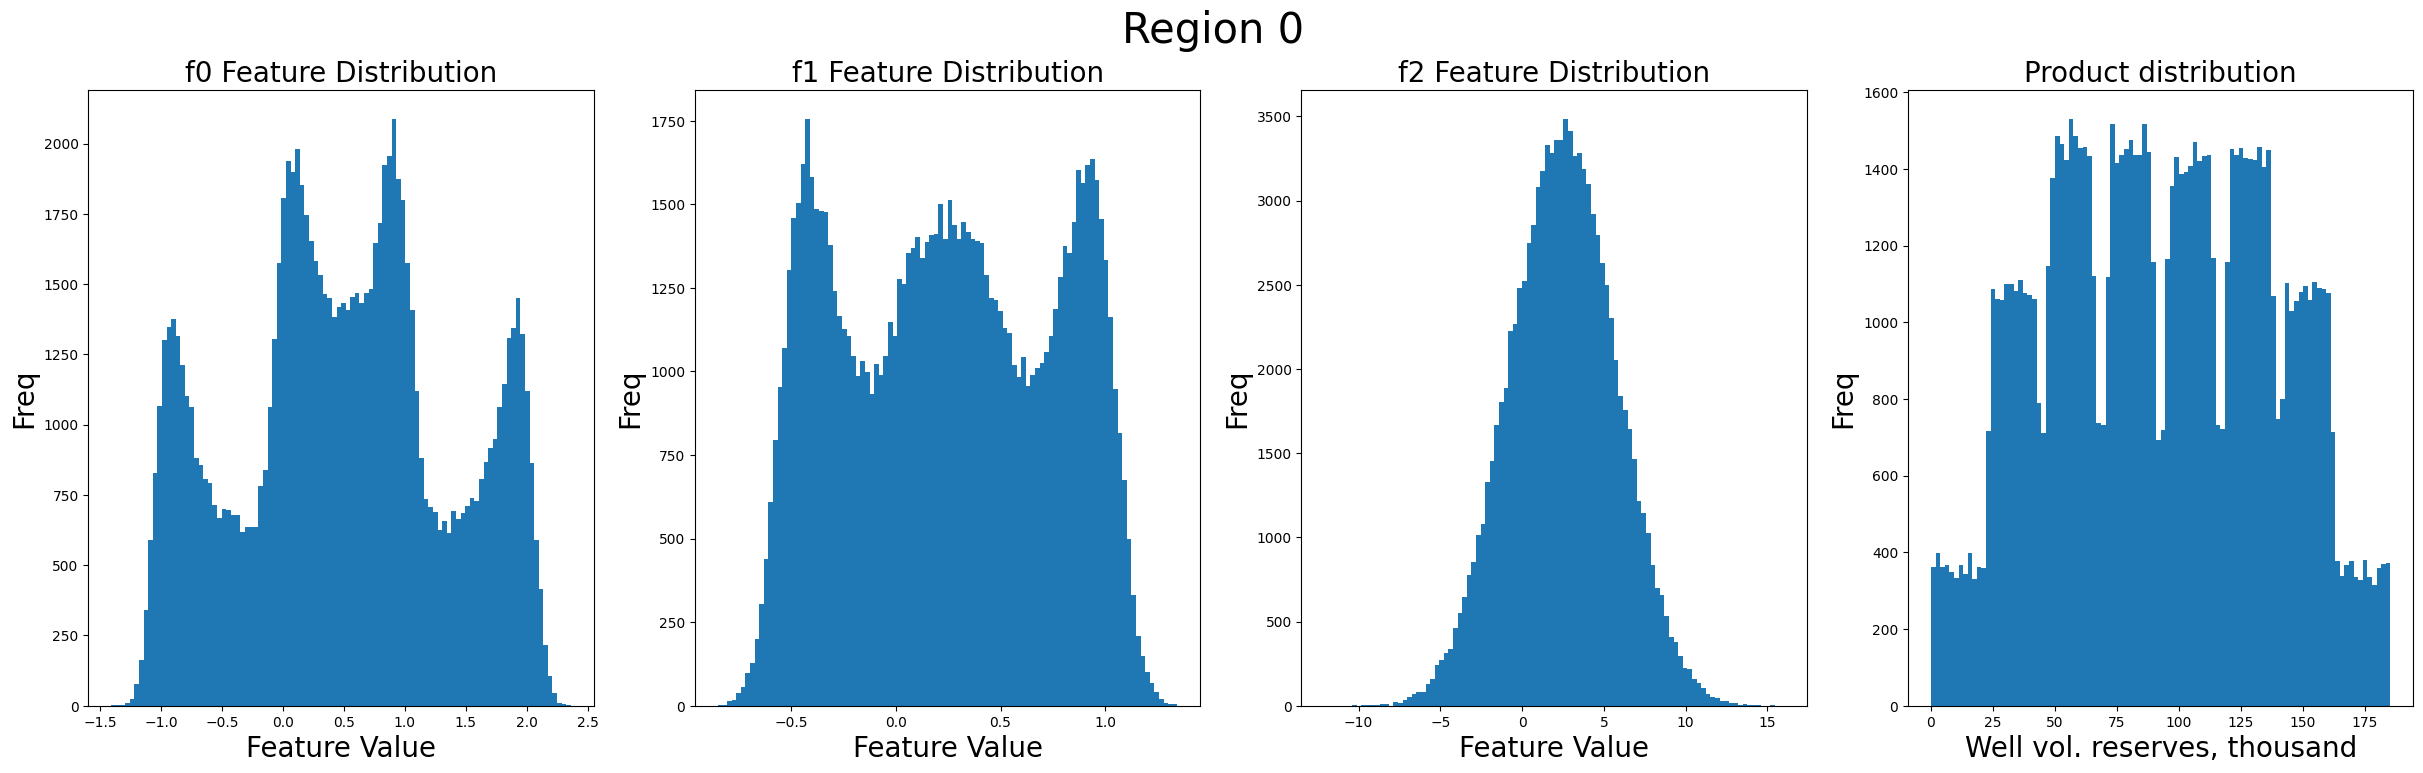

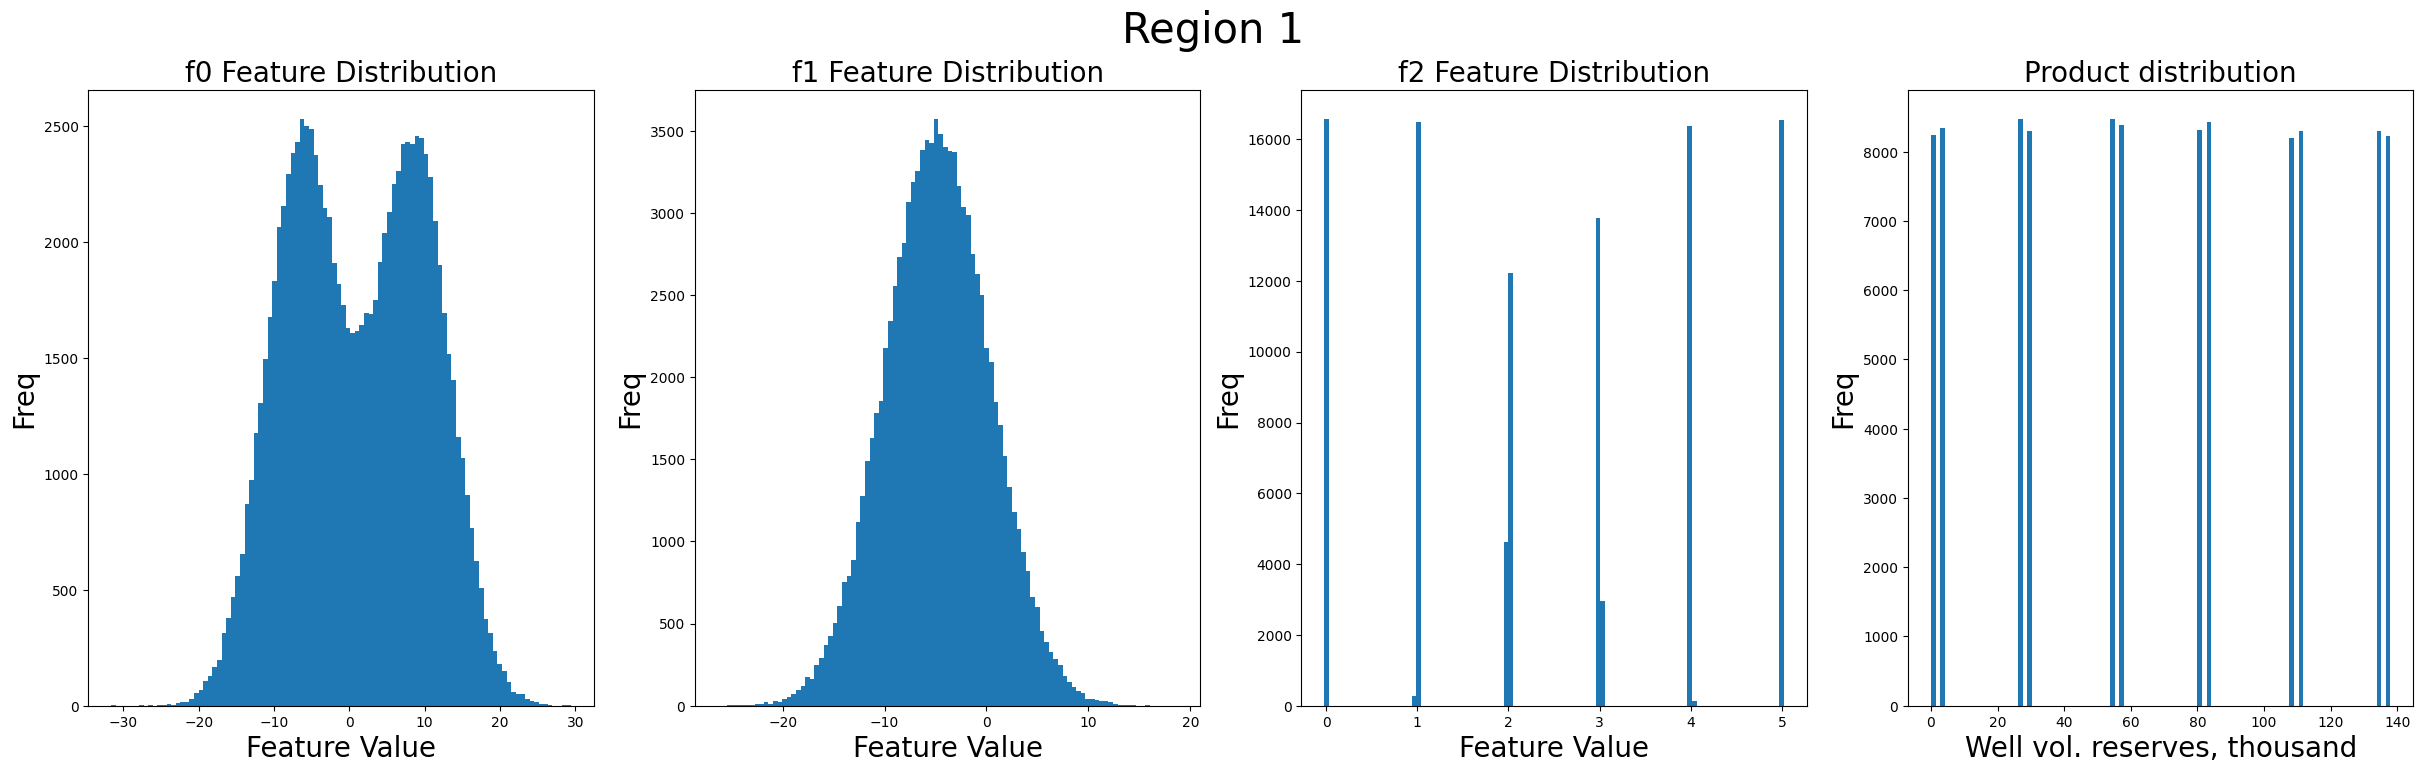

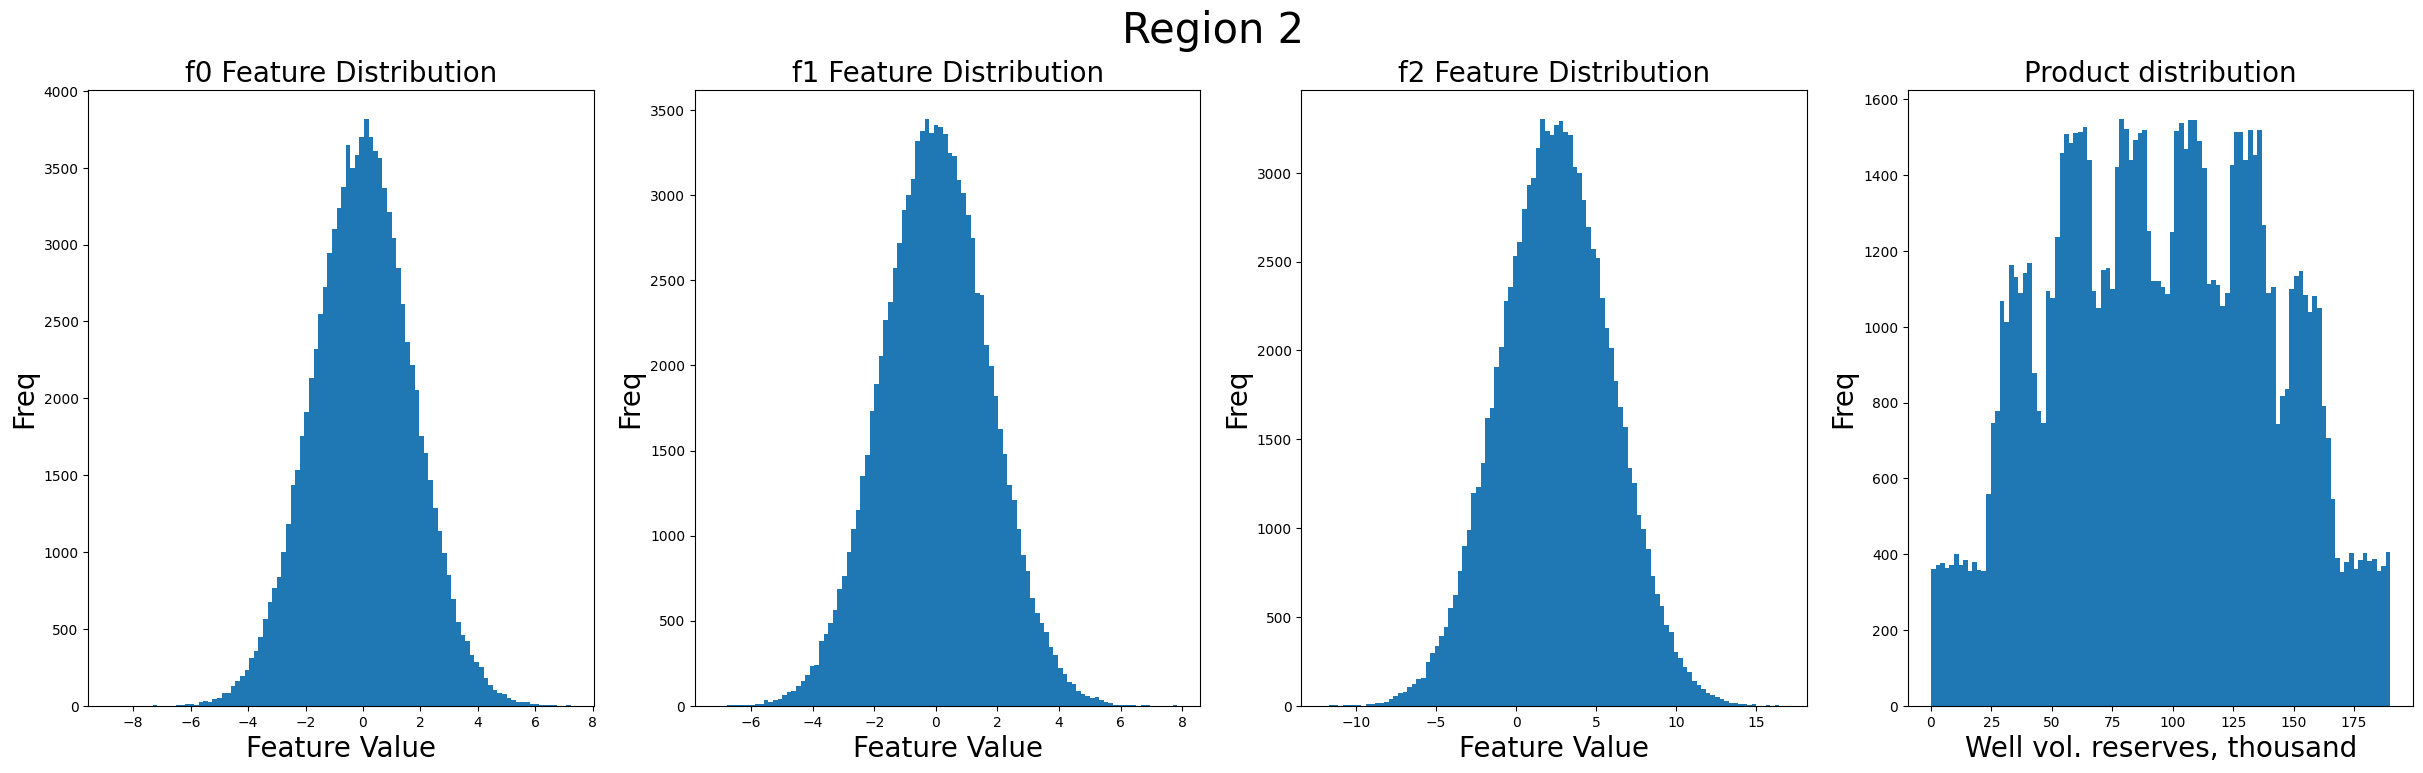

In [31]:
cnt = 0
for region in regions:
    plot_dist(region, cnt)
    cnt+=1

### Вывод
- Удалены дубликаты в данных по id
- Сильной корреляции признаков между собой не наблюдается. Однако, таргет признак - запасы, коррелирует с признаком 2(`f2`). В регионах 0 и 2 эта корреляция не очень сильная, в то время как в регионе 1 эта корреляция приактически 100%. 
- Распределение признака 2 также влияет на распределение по запасам. 
- Если в регионах 0 и 2 распределение похоже на нормальное, с некоторыми пиками в районе среднего, то распределение в регионе 1 не является нормальным. 

## Обучение и проверка модели

In [32]:
class RegressionModel:
    def __init__(self, df: pd.DataFrame, region_cnt):
        self.data = df
        self.model = LinearRegression()
        self.region_cnt = region_cnt
    
    def _ft(self):
        """split DataFrame into features and target"""
        features = self.data.drop(['product', 'id'], axis=1)
        target = self.data['product']
        return features, target
    
    def _train_valid_split(self):
        """splits features and target into train, validation dataframes"""
        features, target = self._ft()
        features_train, features_valid, target_train, target_valid = \
            train_test_split(features, target, test_size=.25, random_state=10)
        
        return (features_train, features_valid, target_train, target_valid)
    
    def _model_predict(self):
        features_train, features_valid, target_train, target_valid = self._train_valid_split()
        self.model.fit(features_train, target_train)
        pred_valid = self.model.predict(features_valid)
        return pred_valid
    
    def model_score(self):
        pred_valid = self._model_predict()
        features_valid = self._train_valid_split()[1]
        target_valid = self._train_valid_split()[3]
        
        print('R2: {:2f}'.format(self.model.score(features_valid, target_valid)))
        return self.model.score(features_valid, target_valid)
    
    def rmse(self):
        pred_valid = self._model_predict()
        target_train = self._train_valid_split()[2]
        target_valid = self._train_valid_split()[3]

        mse_predicted = mean_squared_error(target_valid, pred_valid)
        print('Predicted Model Error. RMSE: {}'.format(mse_predicted ** 0.5))
        
        pred_valid = pd.Series(target_train.mean(), index=target_valid.index)
        mse_constant = mean_squared_error(target_valid, pred_valid)
        print('Constant Model Error. RMSE: {}'.format(mse_constant ** 0.5))
        
        return mse_predicted ** 0.5
    
    def coeffs(self):
        print(f'features importance: {self.model.coef_}')
        return self.model.coef_
    
    def valid_data(self):
        pred_valid = self._model_predict()
        target_valid = self._train_valid_split()[3]
        pred_valid = pd.Series(pred_valid, index=target_valid.index)
        return {
            'predicted': pred_valid,
            'target': target_valid,
        }
    
    def plot(self):
        pred_valid = self._model_predict()
        target_valid = self._train_valid_split()[3]
        plt.figure(figsize=(15,5))
        plt.hist(pred_valid, bins=100);
        plt.xlabel('Product, thousands', fontsize=12);
        plt.ylabel('Freq', fontsize=12);
        plt.title(f'Predicted product per well for Region {self.region_cnt}', fontsize=16);

    def shapes(self):
        features_train, features_valid, target_train, target_valid = self._train_valid_split()
        print (features_train.shape, features_valid.shape, target_train.shape, target_valid.shape)
        
        


Region 0:
Predicted Model Error. RMSE: 37.82069861645482
Constant Model Error. RMSE: 44.29354536011066
features importance: [  3.91361718 -13.91382615   6.6087703 ]

Region 1:
Predicted Model Error. RMSE: 0.889789090064242
Constant Model Error. RMSE: 46.10742828598964
features importance: [-1.45128404e-01 -2.15206940e-02  2.69518671e+01]

Region 2:
Predicted Model Error. RMSE: 40.07674482111465
Constant Model Error. RMSE: 44.859509388623756
features importance: [-0.07332736 -0.06087284  5.72903058]


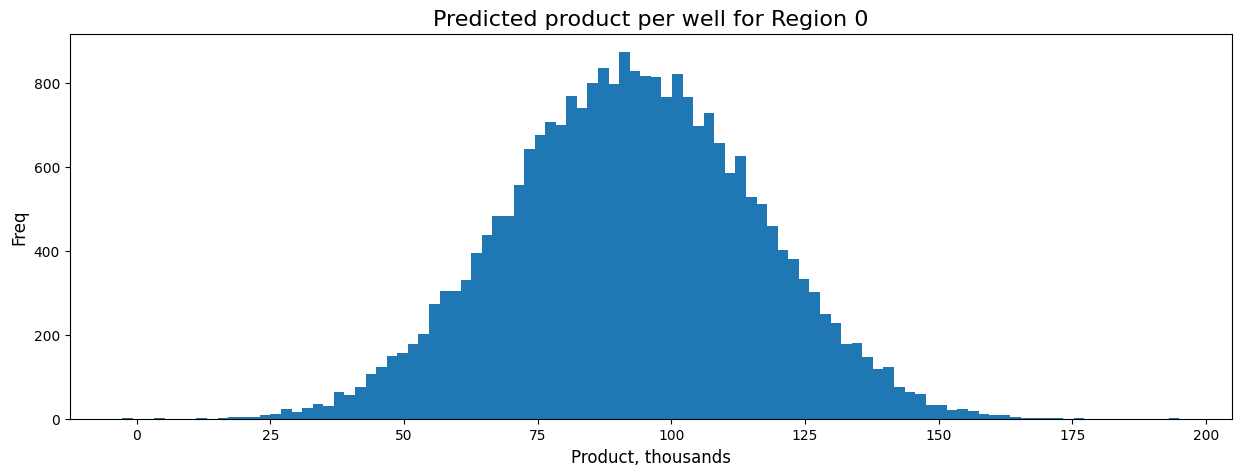

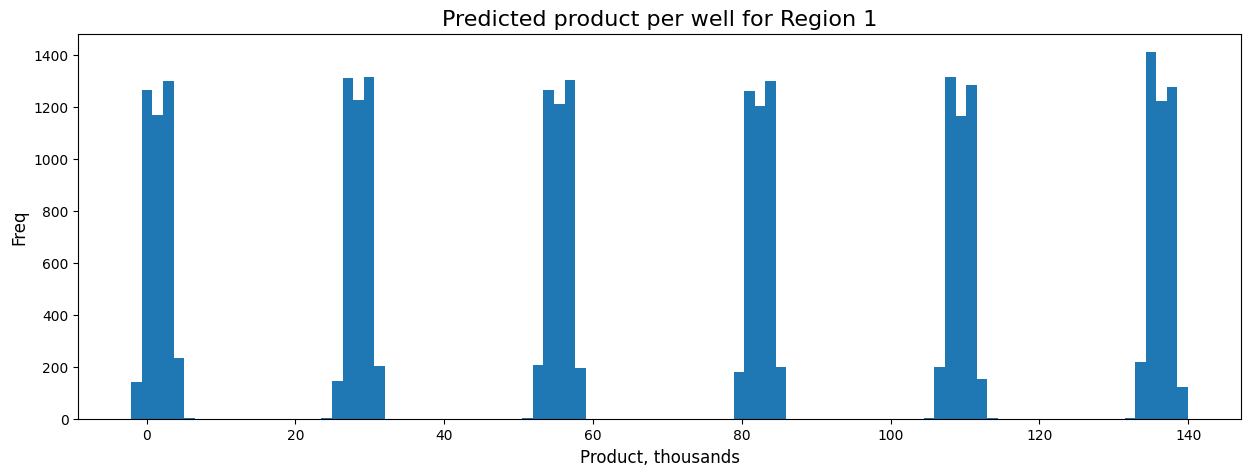

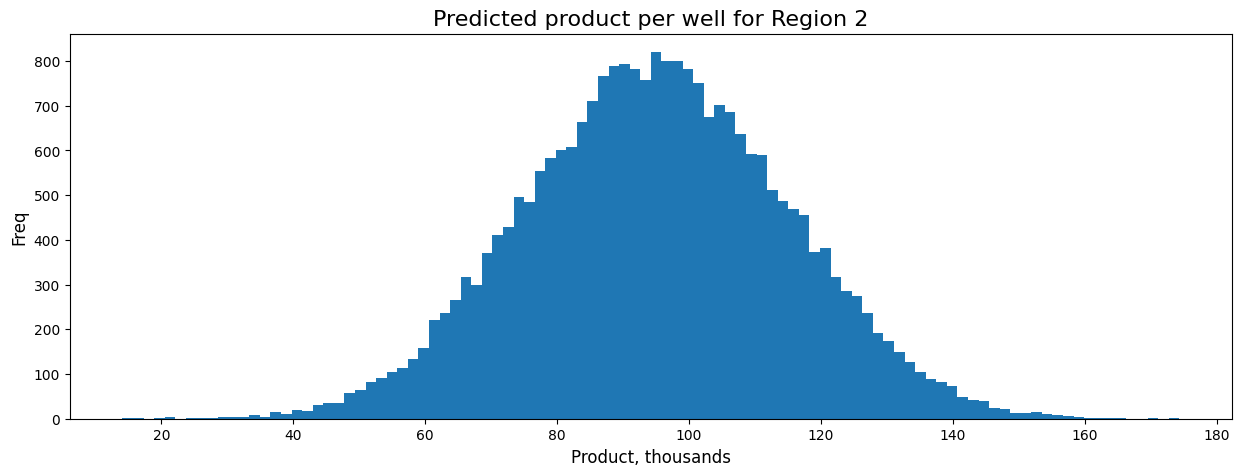

In [33]:
predicted_target = []
rmse_per_region = []

for i, region in enumerate(regions):
    model = RegressionModel(region, i)
    print(f'\nRegion {i}:')
    rmse_per_region.append(model.rmse())
    predicted_target.append(model.valid_data())
    model.coeffs()
    model.plot()

    

In [34]:
mean_products_per_region_predicted = [i['predicted'].mean() for i in predicted_target]
mean_products_per_region_predicted

[np.float64(92.53789337347004),
 np.float64(69.17894457976006),
 np.float64(94.95780205879758)]

In [35]:
mean_products_per_region_true = [i['target'].mean() for i in predicted_target]
mean_products_per_region_true

[np.float64(92.64366715021666),
 np.float64(69.18294218715747),
 np.float64(95.15630784247782)]

In [36]:
rmse_per_region

[37.82069861645482, 0.889789090064242, 40.07674482111465]

### Вывод
- По результатам применения линейной регрессии видно, что признак f2 имеет самое большое влияние на целевой признак. - Распределение целевого признака напрямую зависит от распределения признака f2
- В каждом регионе ошибка RMSE меньше константной модели
- Наибольшие средние запасы в регионе 2

## Подготовка к расчёту прибыли

* При разведке региона исследуют 500 точек, из которых с помощью машинного обучения выбирают 200 лучших для разработки.
* Бюджет на разработку скважин в регионе — 10 млрд рублей.
* При нынешних ценах один баррель сырья приносит 450 рублей дохода. Доход с каждой единицы продукта составляет 450 тыс. рублей, поскольку объём указан в тысячах баррелей.
* После оценки рисков нужно оставить лишь те регионы, в которых вероятность убытков меньше 2.5%. Среди них выбирают регион с наибольшей средней прибылью.

### Рассчитать достаточный объём сырья для безубыточной разработки новой скважины. 
### Сравнить полученный объём сырья со средним запасом в каждом регионе. 

In [37]:
min_product = BUDGET/(SELECTED_WELLS*REVENUE_PER_THOUSAND)
print('Достаточный объём сырья для безубыточной разработки новой скважины: {:2f}'\
      .format(min_product)) 


Достаточный объём сырья для безубыточной разработки новой скважины: 111.111111


In [38]:
mean_products_per_region_true

[np.float64(92.64366715021666),
 np.float64(69.18294218715747),
 np.float64(95.15630784247782)]

In [39]:
rmse_per_region

[37.82069861645482, 0.889789090064242, 40.07674482111465]

In [40]:
mean_products_per_region_predicted

[np.float64(92.53789337347004),
 np.float64(69.17894457976006),
 np.float64(94.95780205879758)]

In [41]:
cnt = 0
for region in regions:
    product = region['product']
    print('Region_{}: mean - {:.2f} for wells higher than minimum threshold. Qty wells higher than threshold {}'\
          .format(cnt, product[product > min_product].mean(), len(product[product > min_product])))
    cnt+=1


Region_0: mean - 140.44 for wells higher than minimum threshold. Qty wells higher than threshold 36579
Region_1: mean - 136.35 for wells higher than minimum threshold. Qty wells higher than threshold 16536
Region_2: mean - 141.87 for wells higher than minimum threshold. Qty wells higher than threshold 38175


### Вывод
- Минимальный порог для точки безубыточности - 111 тыс запасов
- Количество точек в каждом регионе является достаточным, чтобы выбрать 200 наиболее прибыльных
- Средние запасы превышают необходимый минимальный порог
- Средние показатели по всей выборке для каждого региона сильно отличаются от средних показателей запазов на тех точках, которые выше нашего минимального порога по запасам в 111 тыс.
- Необходимо далее более подробно исследовать наиболее крупные по запасам точки месторождений
- Так как массив данных блольшой для каждого региона можно решить методом бутсрап задачу поиска 200 наиболее прибыльных точек месторождения

## Расчёт прибыли по выбранным скважинам и предсказаниям модели

In [42]:
def revenue_wells(target):
    well_revenue = pd.Series(target*REVENUE_PER_THOUSAND, index=target.index)
    return sum(well_revenue)

In [43]:
def revenue_per_region(predicted_target, target_valid):
    region_revenue = []
    for i in range(1000):
        predicted_target_sub = predicted_target.sample(n=500, replace=True).sort_values(ascending=False)
#         print(predicted_target_sub.head())
        target_valid_sorted = target_valid.loc[predicted_target_sub.index].head(200)
#         print(target_valid_sorted.head())
        region_revenue.append(revenue_wells(target_valid_sorted))
    return region_revenue
    
    

In [44]:
def plot_revenue(revenue_series, cnt):
    plt.figure(figsize=(15,8));
    plt.hist(revenue_series, bins=50);
    plt.xlabel('Billion, RUB', fontsize=12);
    plt.ylabel('Freq', fontsize=12);
    plt.title(f'Revenue for Region {cnt}', fontsize=16);

In [46]:
def get_revenues():
    revenues = []
    for region in predicted_target:
        predicted = region['predicted']
        target_valid = region['target']
        revenue_data = revenue_per_region(predicted, target_valid)
        revenues.append(revenue_data)
    return revenues

## Расчёт прибыли и рисков 

In [47]:
revenues = get_revenues()

Mean Revenue of 200 most profitable points: 10.419737 bln, RUB
Mean Revenue of 200 most profitable points: 10.504943 bln, RUB
Mean Revenue of 200 most profitable points: 10.397210 bln, RUB


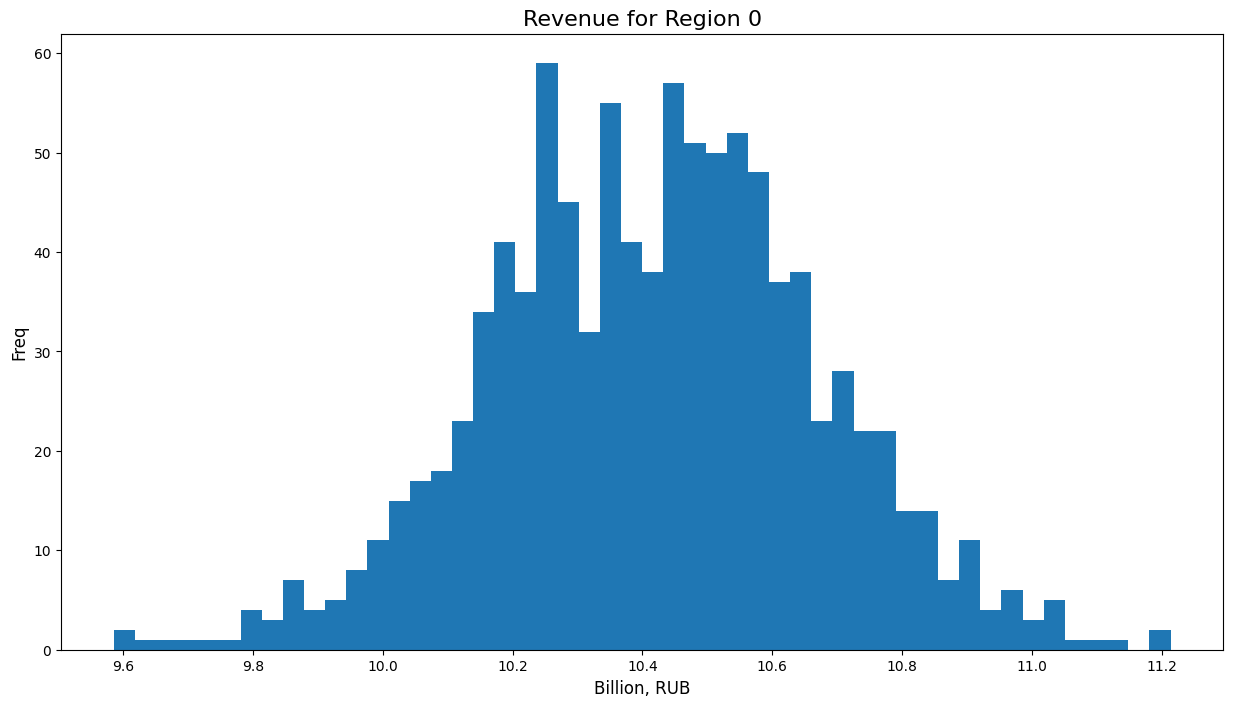

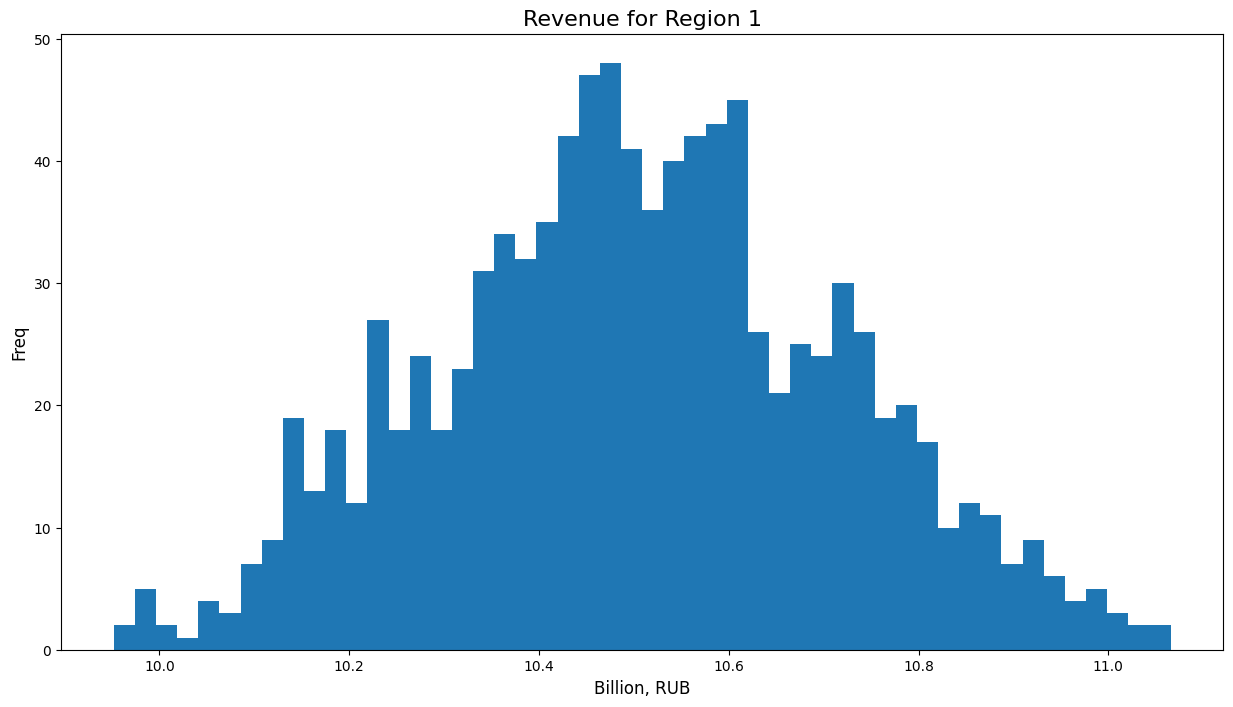

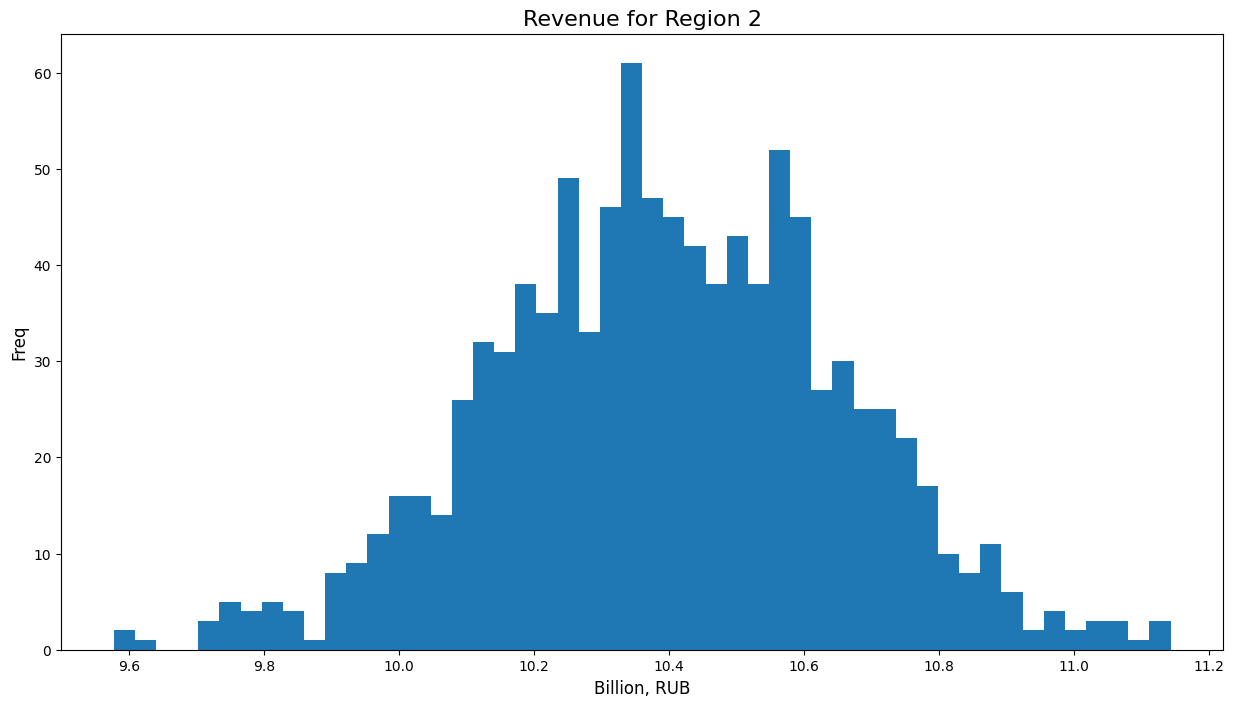

In [48]:
for i, r in enumerate(revenues):
    r = pd.Series(r)/10**9
    print('Mean Revenue of 200 most profitable points: {:2f} bln, RUB'.format(r.mean()))
    plot_revenue(r, i)

In [49]:
cnt = 0
for r in revenues:
    r = pd.Series(r)/10**9
    r_mean = r.mean()
    confidence_interval = st.t.interval(0.95, len(r)-1, r_mean, r.sem())
    print('Mean revenue for region_{}: {}'.format(cnt, r_mean))
    print("95% Confidence Interval for region_{}: {}".format(cnt, confidence_interval))
    print('\n')
    cnt+=1

Mean revenue for region_0: 10.419737293715535
95% Confidence Interval for region_0: (np.float64(10.40403858677536), np.float64(10.43543600065571))


Mean revenue for region_1: 10.504943318017776
95% Confidence Interval for region_1: (np.float64(10.491812269084441), np.float64(10.518074366951112))


Mean revenue for region_2: 10.397210345962849
95% Confidence Interval for region_2: (np.float64(10.381246189674686), np.float64(10.413174502251012))




In [50]:
def loss_probability(series):
    cnt = 0
    r = pd.Series(series)/10**9
    less_10 = np.where(r < 10, 1, 0)
    cnt+=less_10
    return cnt/len(r)
        

In [51]:
cnt = 0

for r in revenues:
    r = pd.Series(r)/10**9
    less_10 = np.where(r < 10, 1, 0)
    prob = sum(less_10[less_10 == 1])/len(r)*100

    print('Loss Probability for region {}: {}'.format(cnt, round(prob, 1)))
    cnt += 1


Loss Probability for region 0: 4.1
Loss Probability for region 1: 0.7
Loss Probability for region 2: 5.5


## Вывод

Предлагается регион `1` для начала разведки месторождения

Причины:
- Вероятность убытков в регионах 0, 2 выше порога в 2,5%. В то же время в регионе 1 вероятность убытков ниже 2,5%
- Также этот регион с более высокой средней потенциальной выручкой от продаж чем остальные регионы